*Workflow*
Load train images -> Normalize -> Augment -> Train
Load test images -> Normalize -> Evaluate

In [1]:
from PIL import Image
import numpy as np
import os
import tensorflow as tf
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import gc



gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)


2026-06-28 13:07:31.074588: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782644851.103808    5415 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782644851.117231    5415 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782644851.237956    5415 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782644851.237998    5415 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782644851.238002    5415 computation_placer.cc:177] computation placer alr

In [ ]:
def load_images(folder):
    images = []
    labels = []
    
    class_names = sorted(os.listdir(folder))
    
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)
        
        if not os.path.isdir(class_path):
            continue
        
        for file in os.listdir(class_path):
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                path = os.path.join(class_path, file)
                
                img = Image.open(path)
                img = np.array(img, dtype=np.float32)
                
                images.append(img)
                labels.append(label)
    
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

In [ ]:
def compute_class_weights(y_train):
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = dict(enumerate(class_weights))
    print(class_weights)
    
    return class_weights

In [ ]:
def build_and_train_model(X_train, y_train, X_test, y_test, class_weights):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(224,224,1)),

        tf.keras.layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

        tf.keras.layers.Conv2D(64, (5,5), strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

        tf.keras.layers.Conv2D(128, (3,3), strides=1, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

        tf.keras.layers.Flatten(), 
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4, activation='softmax')  # Multi-Class classification (4 classes)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=25,
        batch_size=16,
        class_weight=class_weights,
        verbose=1
    )

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.legend(['Train', 'Validation'])
    plt.show()

    return model, history

In [ ]:
# One-Vs-Rest (OvR) Evaluation
def evaluate_model(model, X_test, y_test):
    y_probs = model.predict(X_test)
    y_pred = np.argmax(y_probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
    auc_val = roc_auc_score(y_test_bin, y_probs, average='macro')

    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("AUC:", auc_val)
    print("Confusion Matrix:\n", cm)
    return acc, precision, recall, f1, auc_val

In [ ]:
def save_background_data(X_train, y_train):
    background_size_per_class = 10
    background_indices = []

    for class_label in range(4):
        class_indices = np.where(y_train == class_label)[0]
        selected = np.random.choice(class_indices, background_size_per_class, replace=False)
        background_indices.extend(selected)

    background_data = X_train[background_indices]
    np.save("background_data2.npy", background_data)
    print("Background data saved for SHAP explanations.")

In [ ]:
best_recall = -1
best_fold = None
best_model_path = "aocdml2.keras"


# Loop through each fold and train/evaluate the model
all_fold_results = []
all_y_true = []
all_y_prob = []
for fold in range(1, 6):
    print(f"\n=========== FOLD {fold} ===========")
    tf.keras.backend.clear_session()
    train_dir = rf"cross_val_folds copy/fold_{fold}/train"
    test_dir = rf"cross_val_folds copy/fold_{fold}/test"

    # Load images and labels
    X_train, y_train = load_images(train_dir)
    X_test, y_test = load_images(test_dir)

    # Normalize image data
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # Add channel dimension
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.expand_dims(X_test, axis=-1)

    # Checks
    print(X_train.min(), X_train.max()) # Check normalization
    unique, counts = np.unique(y_train, return_counts=True)
    print(dict(zip(unique, counts))) # Check class distribution
   
    # Compute class weights
    class_weights = compute_class_weights(y_train)
   
    # Build and compile model
    model, history = build_and_train_model(X_train, y_train, X_test, y_test, class_weights)
   
    # Evaluate and save model
    acc, precision, recall, f1, auc_val = evaluate_model(model, X_test, y_test)
    if recall > best_recall:
        print(f"New best model found at fold {fold} (Recall = {recall:.4f})")
        best_recall = recall
        best_fold = fold
        model.save(best_model_path)
        save_background_data(X_train, y_train)
    all_fold_results.append([acc, precision, recall, f1, auc_val])
   
    # Store true labels and predicted probabilities for ROC curve analysis
    y_prob = model.predict(X_test)
    all_y_true.append(y_test)
    all_y_prob.append(y_prob)

    del X_train, y_train, X_test, y_test, model, history
    gc.collect()
    
    # Optional: reset GPU memory stats
    try:
        tf.config.experimental.reset_memory_stats('GPU:0')
    except:
        pass
   
# Print average results across folds
all_fold_results = np.array(all_fold_results)
y_true_all = np.concatenate(all_y_true)
y_prob_all = np.concatenate(all_y_prob)
print("\n===== FINAL CROSS VALIDATION RESULTS =====")
print("Mean Accuracy:", all_fold_results[:,0].mean())
print("Mean Precision:", all_fold_results[:,1].mean())
print("Mean Recall:", all_fold_results[:,2].mean())
print("Mean F1:", all_fold_results[:,3].mean())
print("Mean AUC:", all_fold_results[:,4].mean())
print(f"\nBest model was from Fold {best_fold} with recall = {best_recall:.4f}")
print(f"Saved as: {best_model_path}")


In [ ]:
n_classes = 4
class_names = ['BOT', 'NO', 'OC', 'UF']
y_true_bin = label_binarize(y_true_all, classes=[0,1,2,3])

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-Validated ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Training Accuracy and Validation Accuracy Plotting
train_acc_folds = [
    [0.7565, 0.914, 0.938, 0.9494, 0.9576, 0.9715, 0.9753, 0.9829, 0.9829, 0.988, 0.9873, 0.9867, 0.9943, 0.9937, 0.9943, 0.9962, 0.9943, 0.9968, 0.9981, 0.9975, 0.9975, 0.9987, 0.9987, 0.9987, 0.9987],
    [0.7755, 0.919, 0.9456, 0.9595, 0.9677, 0.9766, 0.9798, 0.9867, 0.9924, 0.9968, 0.9975, 0.9981, 0.9956, 0.9949, 0.9949, 0.9987, 0.9987, 0.9981, 0.9981, 0.9994, 0.9994, 1.0, 1.0, 1.0, 1.0],
    [0.7497, 0.914, 0.9381, 0.9488, 0.9621, 0.9709, 0.9791, 0.9861, 0.9899, 0.993, 0.9968, 0.9968, 0.9956, 0.9975, 0.9987, 1.0, 1.0, 1.0, 0.9987, 1.0, 1.0, 1.0, 0.9994, 1.0, 1.0],
    [0.7484, 0.9229, 0.9381, 0.9532, 0.9602, 0.9678, 0.976, 0.981, 0.9817, 0.9791, 0.9861, 0.9899, 0.993, 0.9968, 0.9987, 0.9987, 0.9987, 0.9987, 0.9987, 0.9987, 0.9987, 0.9987, 0.9987, 0.9987, 0.9987],
    [0.7408, 0.9058, 0.9412, 0.9513, 0.9576, 0.9659, 0.9747, 0.9804, 0.9836, 0.9893, 0.9893, 0.9918, 0.9937, 0.9949, 0.9956, 0.9975, 0.9968, 0.9949, 0.9968, 0.9968, 0.9987, 0.9987, 0.9987, 0.9987, 0.9975],
]

val_acc_folds = [
    [0.8687, 0.8939, 0.899, 0.8939, 0.9318, 0.9217, 0.9343, 0.9495, 0.9444, 0.9571, 0.9596, 0.9646, 0.9621, 0.9646, 0.9621, 0.9621, 0.9672, 0.9495, 0.9596, 0.952, 0.9621, 0.9596, 0.9672, 0.9672, 0.9596],
    [0.8889, 0.9293, 0.9343, 0.9495, 0.952, 0.9545, 0.9571, 0.9545, 0.952, 0.952, 0.9495, 0.9545, 0.9596, 0.947, 0.952, 0.9545, 0.9545, 0.9545, 0.9444, 0.9571, 0.9545, 0.9545, 0.952, 0.9545, 0.952],
    [0.8962, 0.9215, 0.9443, 0.9443, 0.9392, 0.9468, 0.9443, 0.9595, 0.9544, 0.9544, 0.9519, 0.9544, 0.9595, 0.9595, 0.957, 0.957, 0.9595, 0.957, 0.9544, 0.9646, 0.957, 0.962, 0.9671, 0.9595, 0.962],
    [0.8987, 0.9241, 0.9342, 0.9418, 0.9418, 0.9519, 0.9418, 0.9367, 0.9316, 0.9443, 0.9544, 0.957, 0.957, 0.9519, 0.9519, 0.9544, 0.9494, 0.9494, 0.9494, 0.9494, 0.9494, 0.9494, 0.9494, 0.9494, 0.9494],
    [0.8759, 0.9165, 0.9519, 0.957, 0.9646, 0.9671, 0.9671, 0.9646, 0.9646, 0.9418, 0.9342, 0.9468, 0.9367, 0.9468, 0.9392, 0.9367, 0.9418, 0.9241, 0.9342, 0.9392, 0.9519, 0.9468, 0.9671, 0.962, 0.9291],
]


# Convert to numpy arrays for easy calculation
train_acc_folds = np.array(train_acc_folds)
val_acc_folds = np.array(val_acc_folds)

# Compute mean and std per epoch
train_mean = train_acc_folds.mean(axis=0)
train_std = train_acc_folds.std(axis=0)
val_mean = val_acc_folds.mean(axis=0)
val_std = val_acc_folds.std(axis=0)

epochs = np.arange(1, 26)

# Plot with shaded std
plt.figure(figsize=(10,6))
plt.plot(epochs, train_mean, label='Training Accuracy', color='blue')
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(epochs, val_mean, label='Validation Accuracy', color='orange')
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy Across 5 Folds')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Training Loss and Validation Loss Plotting
train_loss_folds = [
    [0.7238, 0.3006, 0.1968, 0.1498, 0.1301, 0.0974, 0.0778, 0.0598, 0.0471, 0.0404, 0.0348, 0.0394, 0.0229, 0.0222, 0.0197, 0.0164, 0.0164, 0.0125, 0.0101, 0.0137, 0.0123, 0.0117, 0.0109, 0.0107, 0.0085],
    [0.6824, 0.2680, 0.1776, 0.1357, 0.1075, 0.0832, 0.0641, 0.0457, 0.0308, 0.0188, 0.0178, 0.0106, 0.0160, 0.0162, 0.0129, 0.0071, 0.0049, 0.0073, 0.0069, 0.0043, 0.0054, 0.0020, 0.0018, 0.0011, 5.4098e-04],
    [0.6932, 0.2861, 0.2043, 0.156, 0.1132, 0.0907, 0.0693, 0.054, 0.0378, 0.0256, 0.019, 0.0146, 0.0154, 0.0103, 0.0085, 0.0051, 0.0032, 0.0033, 0.004, 0.0028, 0.0029, 0.0034, 0.0029, 0.0014, 0.0012],
    [0.7014, 0.2773, 0.2014, 0.152, 0.1178, 0.0965, 0.0774, 0.064, 0.0567, 0.0548, 0.0419, 0.0341, 0.0203, 0.0146, 0.0103, 0.0106, 0.0116, 0.0103, 0.0103, 0.0107, 0.0087, 0.0117, 0.0069, 0.009, 0.0059],
    [0.7224, 0.3099, 0.2055, 0.1543, 0.1338, 0.1156, 0.0921, 0.0672, 0.053, 0.0429, 0.0338, 0.03, 0.0201, 0.017, 0.0162, 0.0118, 0.0102, 0.018, 0.014, 0.0145, 0.0117, 0.0076, 0.0072, 0.0072, 0.0127],
]

val_loss_folds = [
    [0.4204, 0.3194, 0.2692, 0.2635, 0.206, 0.215, 0.1994, 0.1885, 0.1945, 0.1755, 0.1655, 0.1619, 0.1698, 0.1762, 0.1795, 0.1856, 0.1861, 0.226, 0.21, 0.2418, 0.2298, 0.2094, 0.2102, 0.2077, 0.219],
    [0.3528, 0.2203, 0.1805, 0.1664, 0.1489, 0.145, 0.1404, 0.1542, 0.1656, 0.1806, 0.1943, 0.1799, 0.1711, 0.1898, 0.1895, 0.2061, 0.2312, 0.2485, 0.2601, 0.2411, 0.2394, 0.2409, 0.2632, 0.2526, 0.2693],
    [0.3692, 0.2809, 0.2467, 0.2137, 0.178, 0.1574, 0.1486, 0.1386, 0.1373, 0.1437, 0.1464, 0.1534, 0.1597, 0.1573, 0.1523, 0.1696, 0.1822, 0.1875, 0.1662, 0.1862, 0.1837, 0.174, 0.2102, 0.1864, 0.1951],
    [0.3407, 0.2437, 0.2735, 0.2374, 0.2153, 0.1928, 0.1945, 0.2124, 0.2173, 0.1907, 0.1952, 0.1964, 0.2177, 0.2268, 0.245, 0.2528, 0.257, 0.2651, 0.2773, 0.2719, 0.2622, 0.2701, 0.2767, 0.2552, 0.2617],
    [0.4028, 0.264, 0.1638, 0.1422, 0.1347, 0.1237, 0.1111, 0.1048, 0.103, 0.1519, 0.2224, 0.1753, 0.1946, 0.1712, 0.2261, 0.2462, 0.2141, 0.2638, 0.2367, 0.2346, 0.1544, 0.175, 0.1357, 0.1631, 0.3035],
]

# Convert to numpy arrays for easy calculation
train_loss_folds = np.array(train_loss_folds)
val_loss_folds = np.array(val_loss_folds)

# Compute mean and std per epoch
train_mean = train_loss_folds.mean(axis=0)
train_std = train_loss_folds.std(axis=0)
val_mean = val_loss_folds.mean(axis=0)
val_std = val_loss_folds.std(axis=0)

epochs = np.arange(1, 26)

# Plot with shaded std
plt.figure(figsize=(10,6))
plt.plot(epochs, train_mean, label='Training Loss', color='blue')
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.plot(epochs, val_mean, label='Validation Loss', color='orange')
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss Across 5 Folds')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Test Performance Metrics Plotting

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
values = [0.9504, 0.9522, 0.9502, 0.9499, 0.9952]

plt.bar(metrics, values, color=['skyblue', 'orange', 'green', 'red', 'purple'])
plt.ylim(0, 1)
plt.title("Average Test Performance Metrics")
plt.show()


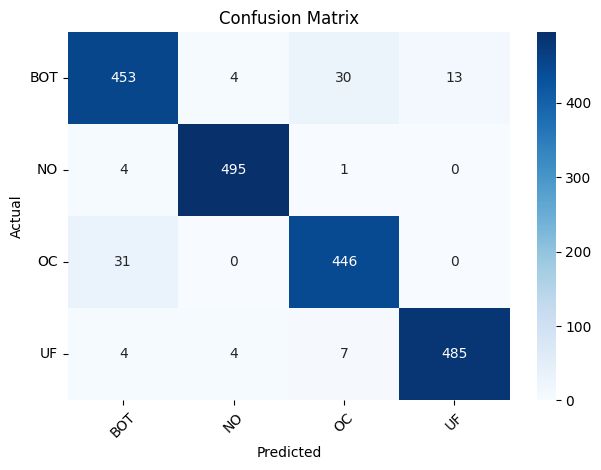

In [2]:
# Confusion Matrix Plotting
cm = np.array([[453,  4, 30, 13],
                [  4,495,  1,  0],
                [ 31,  0,446,  0],
                [  4,  4,  7,485]])

class_names = ['BOT', 'NO', 'OC', 'UF']

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Cross Validation Accuracy Plotting

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
accuracy = [0.9596, 0.9520, 0.9620, 0.9494, 0.9291]

plt.plot(folds, accuracy, marker='o')  # line graph with markers
plt.ylim(0, 1)
plt.title("CNN Accuracy Across 5 Folds")
plt.xlabel("Folds")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()

plt.show()
